# Predikcia diabetu
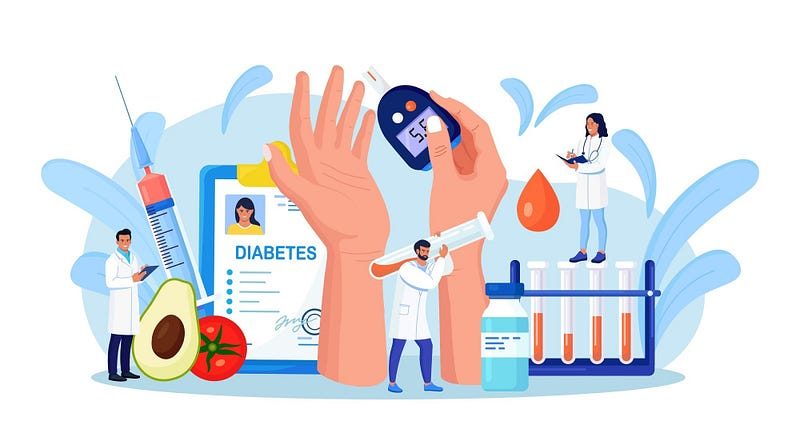

Diabetes je v dnešnej dobe jednou z najčastejších chorôb, ktorá postihuje milióny ľudí. V tejto práci sa budeme venovať vytvoreniu modelu strojového učenia, ktorý na základe rôznych vstupných parametrov (vek, pohlavie, BMI, fajčenie, hypertenzia, srdcové ochorenie, HbA1c a hladina glukózy) klasifikuje, či má jednotlivec diabetes. Na tento účel budeme používať rôzne klasifikačné algoritmy, ako sú Decision Tree, logistická regresia, KNN, Random Forest, Naive Bayes a Support Vector Machine.

Cieľom práce je porovnať, ktorý z týchto algoritmov najlepšie rozpoznáva diabetes. Keďže ľudí s diabetom je v dátach len asi 9 %, samotná presnosť (accuracy) nestačí. Model, ktorý by vždy predpovedal „bez diabetu“, by mal presnosť 91 %. Preto modely porovnávame hlavne podľa F1 skóre pre triedu 1 (diabetes), ktoré spája precision a recall.

Dataset: [Diabetes Prediction Dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset) (Kaggle), súbor `diabetes_prediction_dataset.csv` treba mať v rovnakom priečinku ako notebook.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#importovanie dát
diabetes_data=pd.read_csv("diabetes_prediction_dataset.csv")

In [2]:
diabetes_data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [3]:
diabetes_data.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [4]:
print("Počet duplicitných riadkov:", diabetes_data.duplicated().sum())

diabetes_data = diabetes_data.drop_duplicates().reset_index(drop=True)

print("Po odstránení:", diabetes_data.duplicated().sum())
print("Rozmery datasetu:", diabetes_data.shape)
print("Počet hodnôt 'No Info' v smoking_history:", (diabetes_data['smoking_history'] == 'No Info').sum())

Počet duplicitných riadkov: 3854
Po odstránení: 0
Rozmery datasetu: (96146, 9)
Počet hodnôt 'No Info' v smoking_history: 32887


In [5]:
diabetes_data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,96146.0,41.794326,22.462948,0.08,24.0,43.00,59.00,80.00
hypertension,96146.0,0.077601,0.267544,0.00,0.0,0.00,0.00,1.00
heart_disease,96146.0,0.040803,0.197833,0.00,0.0,0.00,0.00,1.00
bmi,96146.0,27.321461,6.767716,10.01,23.4,27.32,29.86,95.69
HbA1c_level,96146.0,5.532609,1.073232,3.50,4.8,5.80,6.20,9.00
blood_glucose_level,96146.0,138.218231,40.909771,80.00,100.0,140.00,159.00,300.00
diabetes,96146.0,0.088220,0.283616,0.00,0.0,0.00,0.00,1.00


**Priemerný vek:** 41.79 rokov  
**Štandardná odchýlka:** 22.46; čo naznačuje veľký rozptyl vo veku  
**Minimálna hodnota:** 0.08 roka (asi mesačné dieťa)  
**Percentily:**  
25 % ľudí má vek <= 24 rokov  
50 % (medián): 43 rokov  
75 % ľudí má vek <= 59 rokov  
**Maximálny vek:** 80 rokov.  
Polovica ľudí má vek v intervale 24 až 59 rokov. Dataset obsahuje aj deti.

**Hypertenzia:**  
**Priemer:** 0.0776
7.76% osôb má diagnostikovanú hypertenziu. Väčšina ľudí nemá hypertenziu (92.24%)

**Srdcové ochorenie:**  
**Priemer:** 0.0408  
Len malý podiel ľudí (4.08%) má srdcové ochorenie.

**BMI:**  
**Priemer:** 27.32, medián 27.32  
Medián je nad hranicou nadváhy pre dospelých (25), takže viac ako polovica záznamov má BMI nad 25. Keďže sú v dátach aj deti, pre ktoré sa tieto hranice nepoužívajú, ide len o orientačný údaj.

**Glykovaný hemoglobín (HbA1c_level):**  
**Priemer:** 5.53  
Hodnoty HbA1c >= 6.5 sa používajú ako diagnostické kritérium diabetu. 75. percentil je 6.2, takže viac ako tri štvrtiny osôb sú pod touto hranicou.

**Hladina glukózy v krvi:**  
**Priemer:** 138.22, medián 140  
Štvrtina hodnôt je <= 100 mg/dl, polovica <= 140 mg/dl. Maximum je 300 mg/dl. HbA1c aj glukóza nadobúdajú len niekoľko rôznych hodnôt (napr. glukóza 80, 85, 90, 100, 126, 130...), nejde teda o úplne spojité merania.

**Diabetes:**  
**Priemer:** 0.088
8.8% ľudí má diabetes. Triedy sú nevyvážené, preto budeme okrem presnosti sledovať aj precision, recall a F1.

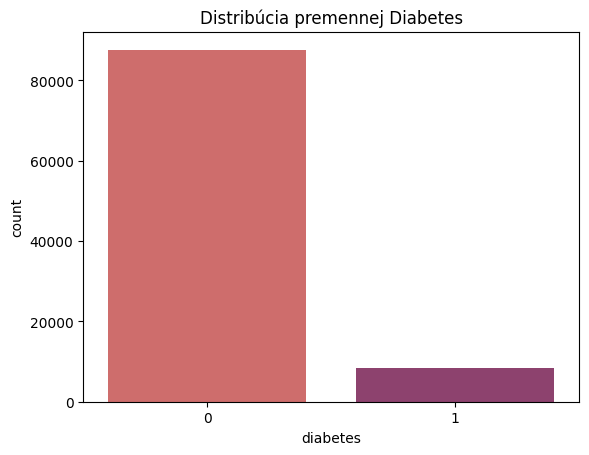

In [6]:
sns.countplot(data=diabetes_data, x='diabetes', hue='diabetes', palette='flare', legend=False)
plt.title('Distribúcia premennej Diabetes')
plt.show()

Tento graf zobrazuje hodnoty premennej diabetes, kde:  
0 označuje ľudí, ktorí nemajú diabetes,  
1 označuje ľudí, ktorí majú diabetes.

Triedy sú výrazne nevyvážené: diabetes má len 8.8 % záznamov.

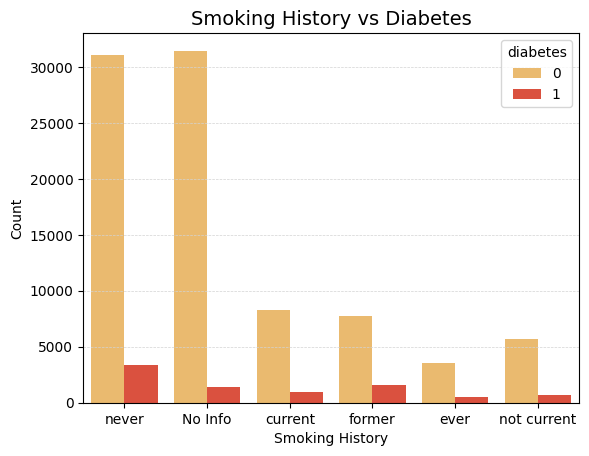

,pocet,podiel_diabetu,median_veku
smoking_history,,,
No Info,32887,4.4,29.0
never,34398,9.7,44.0
current,9197,10.3,44.0
not current,6367,10.8,49.0
ever,3998,11.8,49.0
former,9299,17.1,59.0


In [7]:
sns.countplot(x='smoking_history', hue='diabetes', data=diabetes_data, palette='YlOrRd')
plt.title("Smoking History vs Diabetes", color='black', fontsize=14)
plt.xlabel("Smoking History", color='black')
plt.ylabel("Count", color='black')
plt.grid(color='lightgray', linestyle='--', linewidth=0.5, axis='y')
plt.show()

# podiel diabetikov v každej skupine a medián veku skupiny
smoking_summary = diabetes_data.groupby('smoking_history').agg(
    pocet=('diabetes', 'size'),
    podiel_diabetu=('diabetes', 'mean'),
    median_veku=('age', 'median'))
smoking_summary['podiel_diabetu'] = (smoking_summary['podiel_diabetu'] * 100).round(1)
smoking_summary.sort_values('podiel_diabetu')

Z grafu počtov to vyzerá, že najviac diabetikov je medzi ľuďmi, ktorí nikdy nefajčili, alebo pri ktorých informácia chýba. Je to ale spôsobené tým, že tieto skupiny sú najväčšie. Preto je pod grafom tabuľka s podielom diabetikov v každej skupine.

Najvyšší podiel diabetu majú bývalí fajčiari (`former`), najnižší skupina `No Info`. Tieto rozdiely však do veľkej miery súvisia s vekom: skupina `No Info` má medián veku 29 rokov, `former` 59 rokov. Z týchto dát teda nevieme povedať, aký vplyv má samotné fajčenie. Hodnota `No Info` znamená chýbajúcu informáciu, nie nefajčiara, preto ju ponechávame ako samostatnú kategóriu.

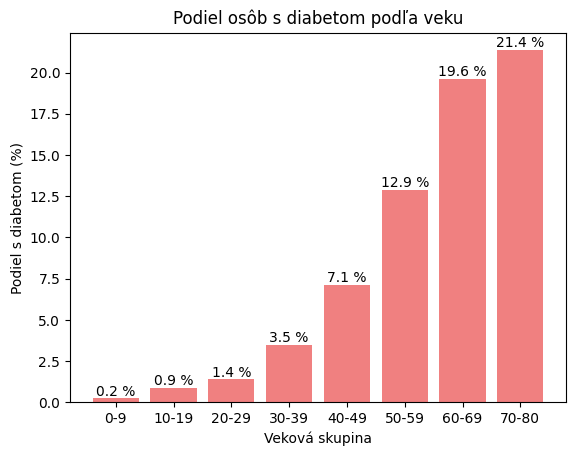

In [8]:
# podiel diabetikov podľa vekovej skupiny
vekove_skupiny = pd.cut(diabetes_data['age'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 81], right=False,
                        labels=['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-80'])
podiel_vek = diabetes_data.groupby(vekove_skupiny, observed=True)['diabetes'].mean() * 100

bars = plt.bar(podiel_vek.index.astype(str), podiel_vek.values, color='lightcoral')
plt.bar_label(bars, fmt='%.1f %%')
plt.title("Podiel osôb s diabetom podľa veku")
plt.xlabel("Veková skupina")
plt.ylabel("Podiel s diabetom (%)")
plt.show()

Podiel diabetikov výrazne rastie s vekom. Do 30 rokov je pod 1,5 %, od 60 rokov je to približne každý piaty človek. Vek preto môže byť pre model užitočnou premennou. Časť tohto vzťahu však môže súvisieť aj s inými premennými, ktoré s vekom rastú (napr. hypertenzia, BMI).

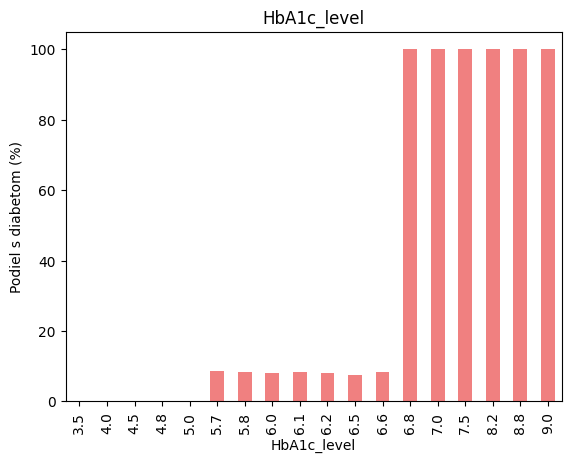

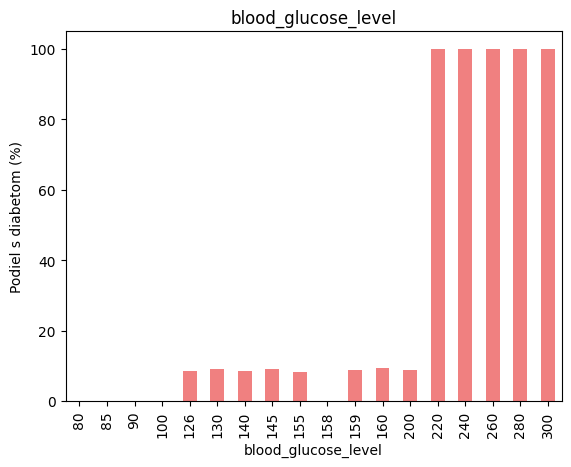

         HbA1c_level      blood_glucose_level     
                 min  max                 min  max
diabetes                                          
0                3.5  6.6                  80  200
1                5.7  9.0                 126  300
Počet takých záznamov: 5671
Z toho s diabetom (%): 100.0
Podiel všetkých diabetikov (%): 66.9


In [9]:
# podiel diabetikov (%) pre každú hodnotu HbA1c a glukózy
podiel_hba1c = diabetes_data.groupby('HbA1c_level')['diabetes'].mean() * 100
podiel_glukoza = diabetes_data.groupby('blood_glucose_level')['diabetes'].mean() * 100

podiel_hba1c.plot(kind='bar', color='lightcoral', title='HbA1c_level', ylabel='Podiel s diabetom (%)')
plt.show()

podiel_glukoza.plot(kind='bar', color='lightcoral', title='blood_glucose_level', ylabel='Podiel s diabetom (%)')
plt.show()

# najmenšia a najväčšia hodnota v každej triede
print(diabetes_data.groupby('diabetes')[['HbA1c_level', 'blood_glucose_level']].agg(['min', 'max']))

# záznamy s hodnotami nad maximom ľudí bez diabetu
vysoke = diabetes_data[(diabetes_data['HbA1c_level'] > 6.6) | (diabetes_data['blood_glucose_level'] > 200)]
pocet_diabetikov = diabetes_data['diabetes'].sum()

print("Počet takých záznamov:", len(vysoke))
print("Z toho s diabetom (%):", round(vysoke['diabetes'].mean() * 100, 1))
print("Podiel všetkých diabetikov (%):", round(vysoke['diabetes'].sum() / pocet_diabetikov * 100, 1))

Ľudia bez diabetu majú HbA1c najviac 6.6 a glukózu najviac 200. Každý záznam, ktorý má vyššiu hodnotu aspoň jednej z nich, patrí v tomto datasete do triedy diabetes. Takto sa dajú nájsť asi dve tretiny všetkých diabetikov. Naopak, pri HbA1c pod 5.7 alebo glukóze pod 126 nie je v dátach ani jeden diabetik.

Zvyšná tretina diabetikov má hodnoty v rovnakom rozsahu ako zdraví ľudia (HbA1c 5.7–6.6, glukóza 126–200). Tieto prípady bude pre modely pravdepodobne ťažšie rozpoznať.

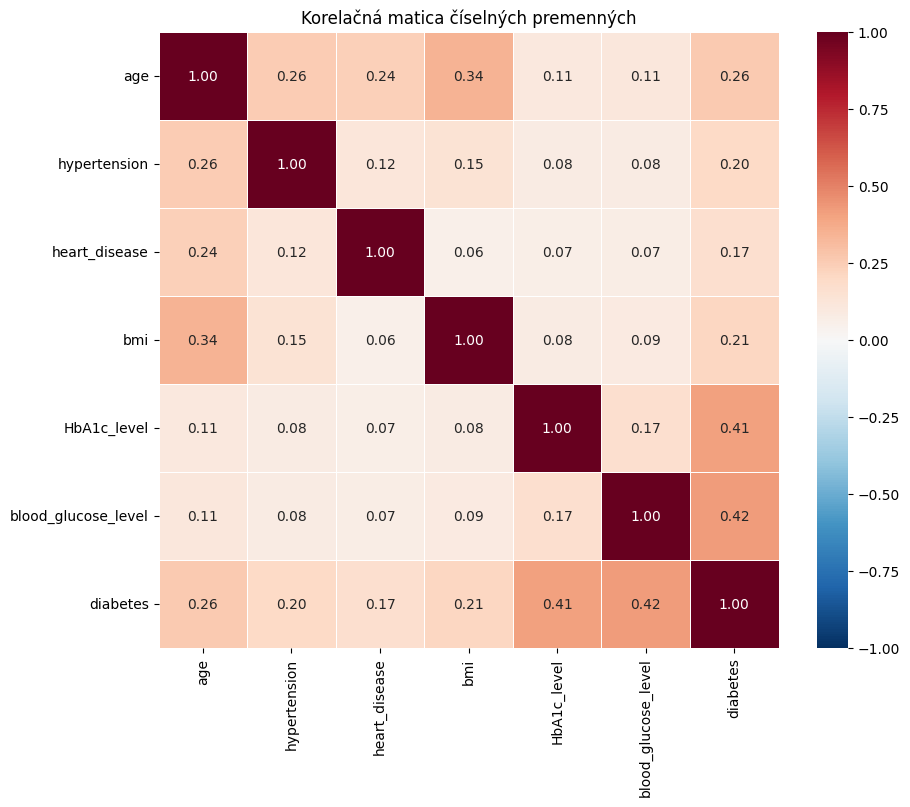

In [10]:
# Korelačná matica (iba pôvodné číselné premenné, kategórie gender a smoking_history nemajú poradie)
numeric_data = diabetes_data.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, center=0, linewidths=0.5)
plt.title("Korelačná matica číselných premenných")
plt.show()

Táto tabuľka zobrazuje Pearsonove korelácie medzi jednotlivými premennými. Korelačné hodnoty sú zobrazené ako čísla v matici a farebne zvýraznené, kde:  
   Červená - pozitívna korelácia (hodnoty blízke +1).  
   Biela - slabá alebo žiadna korelácia (hodnoty blízke 0).  
   Modrá - negatívna korelácia (hodnoty blízke -1). V týchto dátach sa takmer nevyskytuje.

#### Diabetes a nezávislé premenné:
**blood_glucose_level**: Korelácia 0.42 - stredne silná pozitívna korelácia. Vyššie hladiny glukózy v krvi sú častejšie spojené s cukrovkou.  
**HbA1c_level**: Korelácia 0.41 - stredne silná pozitívna. Vysoké hodnoty HbA1c (dlhodobý ukazovateľ glukózy) sú spojené s cukrovkou.  
**age**: Korelácia 0.26 - slabšia pozitívna korelácia, starší ľudia majú častejšie cukrovku.  
**bmi**: Korelácia 0.21 - slabšia pozitívna korelácia, vyššie BMI je mierne spojené s cukrovkou.

#### Vzájomné korelácie medzi nezávislými premennými
**age a bmi:** Korelácia 0.34 - mierna pozitívna korelácia. Starší ľudia majú tendenciu mať vyššie BMI.  
**age a hypertension:** Korelácia 0.26 - vek je mierne spojený s výskytom hypertenzie.  
**Ostatné korelácie:** Väčšina hodnôt je blízka nule. Medzi vstupnými premennými teda nie je silná závislosť (multikolinearita).



In [11]:
# One-hot encoding pre premenné "gender" a "smoking_history"
diabetes_data = pd.get_dummies(diabetes_data, columns=['gender', 'smoking_history'], dtype=int)

diabetes_data.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,1,0,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,1,0,0,1,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,0,0,1,0,0,0,0,0,1,0
3,36.0,0,0,23.45,5.0,155,0,1,0,0,0,1,0,0,0,0
4,76.0,1,1,20.14,4.8,155,0,0,1,0,0,1,0,0,0,0


In [12]:
#matica nezávislých premenných 
X = diabetes_data.drop('diabetes', axis=1)

In [13]:
#závislá premenná - cieľová premenná 
y=diabetes_data["diabetes"]

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20, random_state=123, stratify=y)

In [15]:
print(X_test.shape, y_test.shape)
print(X_train.shape, y_train.shape)

(19230, 15) (19230,)
(76916, 15) (76916,)


Dataset bol rozdelený na 80 % pre tréning a 20 % pre testovanie. Parameter `stratify=y` zabezpečí, že podiel diabetikov je v oboch častiach rovnaký. Testovacie dáta používame iba na záverečné vyhodnotenie modelov. Parametre (napr. počet susedov k) vyberáme na tréningových dátach, inak by bol výsledok na teste príliš optimistický.

In [16]:
from sklearn.preprocessing import MinMaxScaler #normalizácia dát
scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import naive_bayes
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix, make_scorer

In [18]:
knn = KNeighborsClassifier(3)
knn.fit(X_train_normalized, y_train)
y_pred1 = knn.predict(X_test_normalized)
print("Presnost:", accuracy_score(y_test, y_pred1))
print("F1 (diabetes):", f1_score(y_test, y_pred1))

Presnost: 0.9560582423296932
F1 (diabetes): 0.7178631051752922


KNN algoritmus s 3 najbližšími susedmi dosiahol na testovacích dátach presnosť 95.6 %. Pri nevyvážených triedach však vysoká presnosť sama o sebe veľa nehovorí. Podrobnejšie výsledky sú v kontingenčnej matici nižšie.

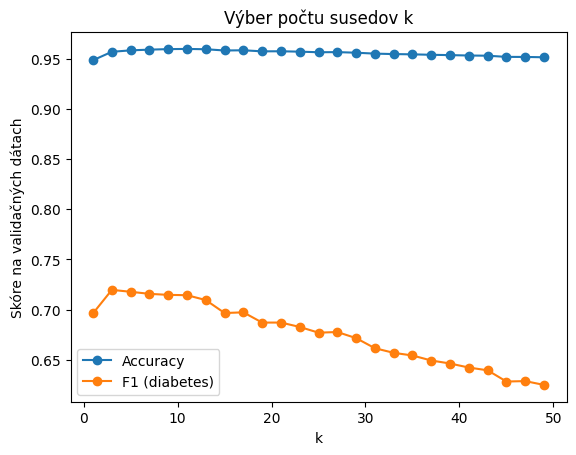

In [19]:
#výber optimálneho parametra k pre KNN model
# k vyberáme na validačnej časti vyčlenenej z tréningových dát, testovacie dáta pri výbere nepoužívame
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=123, stratify=y_train)
# normalizácia naučená len na tejto menšej tréningovej časti
scaler_k = MinMaxScaler()
X_tr_normalized = scaler_k.fit_transform(X_tr)
X_val_normalized = scaler_k.transform(X_val)

kVals = np.arange(1, 50, 2)
accuracies = []
f1_scores = []
for k in kVals:
  knn1 = KNeighborsClassifier(k)
  knn1.fit(X_tr_normalized, y_tr)
  y_pred_val = knn1.predict(X_val_normalized)
  accuracies.append(accuracy_score(y_val, y_pred_val))
  f1_scores.append(f1_score(y_val, y_pred_val))

plt.plot(kVals, accuracies, marker='o', label='Accuracy')
plt.plot(kVals, f1_scores, marker='o', label='F1 (diabetes)')
plt.xlabel('k')
plt.ylabel('Skóre na validačných dátach')
plt.title('Výber počtu susedov k')
plt.legend()
plt.show()

In [20]:
best_k_acc = kVals[np.argmax(accuracies)]
best_k = kVals[np.argmax(f1_scores)]
print(f"Najvyššia presnosť: {max(accuracies):.4f} pri hodnote K = {best_k_acc}")
print(f"Najvyššie F1: {max(f1_scores):.4f} pri hodnote K = {best_k}")

Najvyššia presnosť: 0.9597 pri hodnote K = 11
Najvyššie F1: 0.7196 pri hodnote K = 3


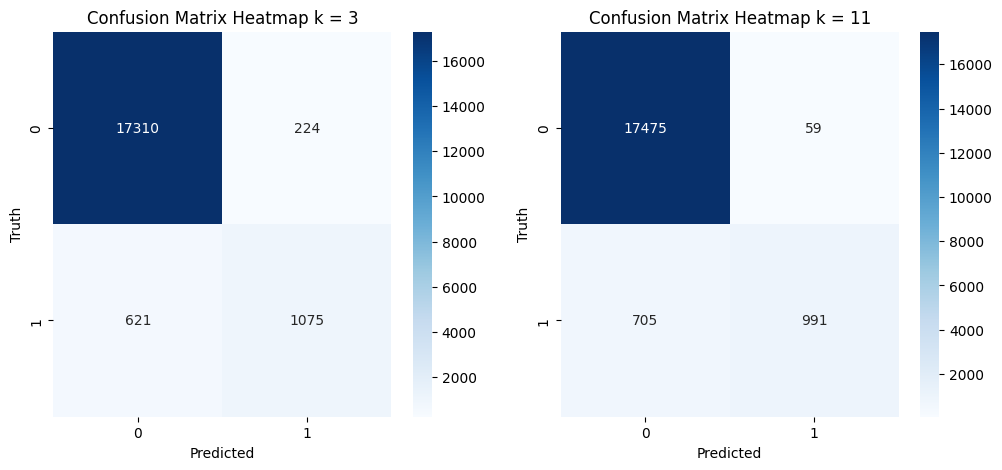

k = 3
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17534
           1       0.83      0.63      0.72      1696

    accuracy                           0.96     19230
   macro avg       0.90      0.81      0.85     19230
weighted avg       0.95      0.96      0.95     19230

k = 11
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     17534
           1       0.94      0.58      0.72      1696

    accuracy                           0.96     19230
   macro avg       0.95      0.79      0.85     19230
weighted avg       0.96      0.96      0.96     19230



In [21]:
# k = 3 (najlepšie F1 na validácii) porovnávame s k vybraným podľa presnosti
knn2 = KNeighborsClassifier(n_neighbors=best_k_acc)
knn2.fit(X_train_normalized, y_train)
y_pred2 = knn2.predict(X_test_normalized)

cm1 = confusion_matrix(y_test, y_pred1)
cm2 = confusion_matrix(y_test, y_pred2)
classes = np.unique(y_test)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm1, annot=True, fmt='d', cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix Heatmap k = 3")
plt.xlabel("Predicted")
plt.ylabel("Truth")

plt.subplot(1, 2, 2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title(f'Confusion Matrix Heatmap k = {best_k_acc}')
plt.show()

print("k = 3")
print(classification_report(y_test, y_pred1))
print(f"k = {best_k_acc}")
print(classification_report(y_test, y_pred2))

Na validačných dátach je accuracy pri všetkých k podobná (okolo 0.95–0.96) a najvyššia je pri k = 11. F1 skóre je najvyššie pri k = 3 a pri väčších k postupne klesá. Pri väčšom počte susedov častejšie prevládne väčšinová trieda, takže model menej často predpovedá diabetes. Na testovacích dátach preto porovnávame k = 3 (najlepšie F1 na validácii) a k = 11 (najlepšia accuracy na validácii).

### Kontingenčná matica pre k = 3
**True Negatives** - model správne predpovedal, že 17 310 osôb nemá cukrovku  
**False Positives** - model nesprávne predpovedal, že 224 osôb má cukrovku, aj keď v skutočnosti nemajú  
**False Negatives** - model nesprávne predpovedal, že 620 osôb nemá cukrovku, aj keď v skutočnosti majú  
**True Positives** - model správne predpovedal, že 1 076 osôb má cukrovku

### Kontingenčná matica pre k = 11
**True Negatives** - model správne predpovedal, že 17 475 osôb nemá cukrovku  
**False Positives** - model nesprávne predpovedal, že 59 osôb má cukrovku, aj keď v skutočnosti nemajú  
**False Negatives** - model nesprávne predpovedal, že 705 osôb nemá cukrovku, aj keď v skutočnosti majú  
**True Positives** - model správne predpovedal, že 991 osôb má cukrovku

Oba modely majú na teste F1 približne 0.72, líšia sa však typom chýb. Model s k = 11 má menej falošných poplachov (59 oproti 224), ale neodhalí viac diabetikov (705 oproti 620). Ktorý je vhodnejší, závisí od toho, ktorá chyba je v danom použití horšia. Napríklad pri skríningu by sa pravdepodobne uprednostnil vyšší recall (k = 3).

## Optimalizácia KNN algoritmu:

- n_neighbors (počet susedov): hlavný parameter, ktorý určuje počet susedov na rozhodovanie o triede

- weights: určuje, či majú všetci susedia rovnakú váhu ('uniform') alebo či váha susedov klesá s ich vzdialenosťou ('distance')

- metric: definuje metódu výpočtu vzdialenosti medzi bodmi (Euklidovská alebo Manhattanovská vzdialenosť).

Kombinácie parametrov vyhodnocujeme 5-násobnou krížovou validáciou na tréningových dátach a vyberáme podľa F1 skóre.

In [22]:
param_grid = {
    'n_neighbors': sorted({3, 5, 10, 15, 20, 25, int(best_k), int(best_k_acc)}),  # Počet susedov
    'weights': ['uniform', 'distance'],  # Rôzne váhy
    'metric': ['euclidean', 'manhattan'] # Typ vzdialenosti
}

In [23]:
grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_normalized, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 10, 11, 15, 20, 25],
                         'weights': ['uniform', 'distance']},
             scoring='f1')

In [24]:
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Najlepšie parametre:", best_params)
print("Najlepšie F1 (krížová validácia):", round(best_score, 4))

Najlepšie parametre: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Najlepšie F1 (krížová validácia): 0.7302


Najlepšia kombinácia parametrov podľa priemerného F1 v 5-násobnej krížovej validácii bola:  
**metric:** Euklidovská vzdialenosť.  
**n_neighbors:** 5 najbližších susedov.  
**weights:** Uniformné váhy, kde všetci susedia majú rovnaký vplyv.

Platí to len v rámci otestovanej mriežky parametrov. Priemerné F1 v krížovej validácii bolo 0.73 a na testovacích dátach je F1 tiež 0.73. Výkon na nových dátach je teda podobný ako pri validácii. Precision pre diabetes je 0.89, recall 0.61: model má málo falošných poplachov, ale asi 39 % diabetikov v teste neodhalí.

In [25]:
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_normalized)

# Vyhodnotenie modelu
print("Presnost:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Presnost: 0.9592823712948518
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     17534
           1       0.89      0.61      0.73      1696

    accuracy                           0.96     19230
   macro avg       0.93      0.80      0.85     19230
weighted avg       0.96      0.96      0.96     19230



In [26]:
algos = ["Dummy (vždy 0)","Support Vector Machine","Decision Tree","Logistic Regression","K Nearest Neighbor","Naive Bayes","Random Forest"]

clfs = [DummyClassifier(strategy="most_frequent"), svm.LinearSVC(random_state=1), DecisionTreeClassifier(random_state=1),
        LogisticRegression(max_iter=1000), KNeighborsClassifier(**best_params),
        naive_bayes.GaussianNB(), RandomForestClassifier(random_state=1)]
result = []

# Modely porovnávame 5-násobnou krížovou validáciou na (normalizovaných) tréningových dátach
for clff in clfs:
    scores = cross_validate(clff, X_train_normalized, y_train, cv=5,
                            scoring={'accuracy': 'accuracy', 'precision': make_scorer(precision_score, zero_division=0),
                                     'recall': 'recall', 'f1': 'f1'}, n_jobs=-1)
    result.append([scores['test_accuracy'].mean(), scores['test_precision'].mean(),
                   scores['test_recall'].mean(), scores['test_f1'].mean(), scores['test_f1'].std()])

result_df = pd.DataFrame(result, index=algos, columns=["Accuracy", "Precision", "Recall", "F1", "F1_std"])

result_df.sort_values(by="F1",ascending=False).round(4)

,Accuracy,Precision,Recall,F1,F1_std
Random Forest,0.9689,0.9467,0.6863,0.7956,0.0105
Logistic Regression,0.9592,0.8762,0.6263,0.7303,0.0133
K Nearest Neighbor,0.9599,0.8972,0.6160,0.7302,0.0146
Support Vector Machine,0.9596,0.9001,0.6092,0.7265,0.0134
Decision Tree,0.9492,0.7006,0.7402,0.7198,0.0092
Naive Bayes,0.5562,0.1637,0.9805,0.2806,0.0041
Dummy (vždy 0),0.9118,0.0000,0.0000,0.0000,0.0000


Modely sme porovnali 5-násobnou krížovou validáciou na tréningových dátach a zoradili podľa priemerného F1. Stĺpec `F1_std` je smerodajná odchýlka F1 medzi foldmi. Testovacie dáta sme pri porovnaní nepoužili.

- **Random Forest** má najvyššie priemerné F1 (0.80). Náskok pred ďalšími modelmi (asi 0.065) je výrazne väčší ako rozptyl medzi foldmi (okolo 0.01), preto ho ďalej optimalizujeme.
- Logistická regresia, KNN a SVM majú F1 0.73. Rozdiely medzi nimi (menej ako 0.005) sú menšie ako rozptyl medzi foldmi, takže podľa týchto výsledkov ich nevieme spoľahlivo zoradiť.
- **Decision Tree** má vyšší recall (0.74), ale nižšiu precision (0.70) ako ostatné modely. Nijako neobmedzený strom sa môže prispôsobiť tréningovým dátam príliš.
- **Naive Bayes** má recall 0.98, ale precision len 0.16, takže diabetes predpovedá veľmi často. Jedným z možných dôvodov je, že predpoklad nezávislosti a normálneho rozdelenia premenných tu nie je splnený (napr. HbA1c a glukóza nadobúdajú len niekoľko hodnôt).
- **Dummy** model má accuracy 91 % a F1 0. Ukazuje, prečo samotná accuracy pri nevyvážených dátach nestačí.

Recall všetkých modelov okrem Naive Bayes a Decision Tree je okolo 0.6–0.7. To je v súlade so zistením z prieskumu dát, že asi tretina diabetikov má HbA1c aj glukózu v rovnakom rozsahu ako ľudia bez diabetu.

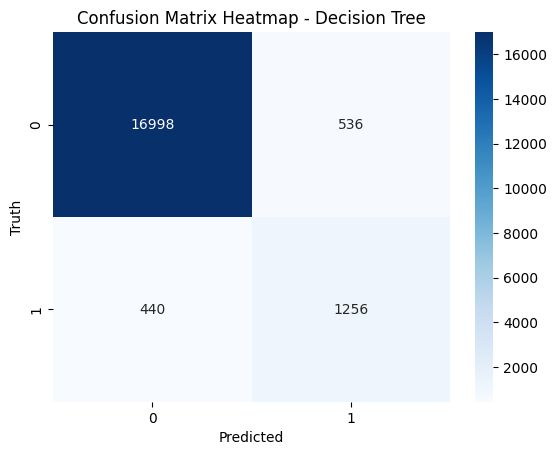

0.9492459698387935
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     17534
           1       0.70      0.74      0.72      1696

    accuracy                           0.95     19230
   macro avg       0.84      0.85      0.85     19230
weighted avg       0.95      0.95      0.95     19230



In [27]:
dtc= DecisionTreeClassifier(random_state=1)
dtc.fit(X_train, y_train)
y_pred_dtc = dtc.predict(X_test)


cm = confusion_matrix(y_test, y_pred_dtc)
classes = np.unique(y_test)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix Heatmap - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

print(accuracy_score(y_test, y_pred_dtc))
print(classification_report(y_test, y_pred_dtc))

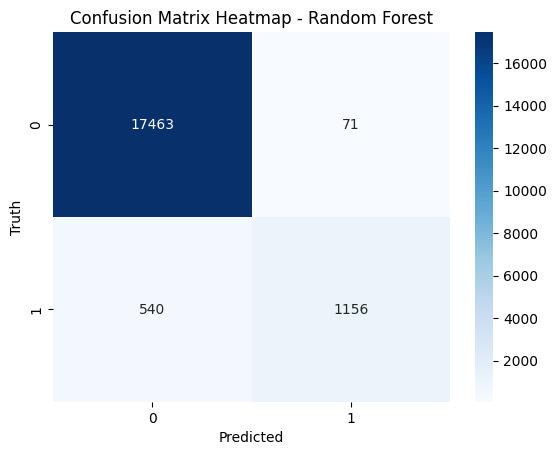

0.9682267290691627
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       0.94      0.68      0.79      1696

    accuracy                           0.97     19230
   macro avg       0.96      0.84      0.89     19230
weighted avg       0.97      0.97      0.97     19230



In [28]:
rf= RandomForestClassifier(random_state=1)
rf.fit(X_train, y_train)
y_pred_rfr = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rfr)
classes = np.unique(y_test)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix Heatmap - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

print(accuracy_score(y_test, y_pred_rfr))
print(classification_report(y_test, y_pred_rfr))

Na testovacích dátach má Decision Tree F1 0.72 (precision 0.70, recall 0.74) a Random Forest F1 0.79 (precision 0.94, recall 0.68), čo zodpovedá výsledkom krížovej validácie. Random Forest kombinuje veľa stromov, z ktorých každý sa učí na inej náhodnej vzorke dát. Takýto model zvyčajne menej kopíruje tréningové dáta ako jeden strom.

## Optimalizácia Random Forest algoritmu:

In [29]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'class_weight': [None, 'balanced'],
}

Definovanie hyperparametrov na optimalizáciu:

- n_estimators: Počet stromov v lese.
- max_depth: Maximálna hĺbka stromu.
- min_samples_split: Minimálny počet vzoriek potrebných na rozdelenie vnútorného uzla.
- class_weight: `'balanced'` dáva väčšiu váhu menšinovej triede (diabetes). Môže zvýšiť recall, ale zvyčajne za cenu nižšej precision.

Rovnako ako pri KNN vyberáme najlepšiu kombináciu podľa F1 skóre (3-násobná krížová validácia). Stromové modely normalizáciu nepotrebujú, preto používame pôvodné `X_train`.

In [30]:
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=1), param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=1), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'max_depth': [None, 10], 'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [31]:
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Najlepšie parametre:", best_params)
print("Najlepšie F1 (krížová validácia):", round(best_score, 4))

Najlepšie parametre: {'class_weight': None, 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Najlepšie F1 (krížová validácia): 0.8031


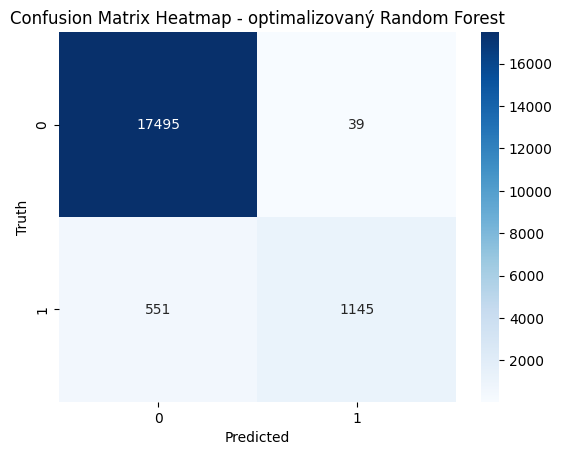

0.96931877275091
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       0.97      0.68      0.80      1696

    accuracy                           0.97     19230
   macro avg       0.97      0.84      0.89     19230
weighted avg       0.97      0.97      0.97     19230



In [32]:
rf = grid_search.best_estimator_   # model s najlepšími parametrami, natrénovaný na celom X_train
prediction_rm=rf.predict(X_test)

cm = confusion_matrix(y_test, prediction_rm)
classes = np.unique(y_test)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix Heatmap - optimalizovaný Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

print(accuracy_score(y_test, prediction_rm))
print(classification_report(y_test, prediction_rm))

Najlepšie parametre podľa F1 v krížovej validácii: `n_estimators=100`, `max_depth=None`, `min_samples_split=5`, `class_weight=None`. Váženie tried (`balanced`) v tejto mriežke F1 nezlepšilo.

Optimalizovaný Random Forest dosahuje na testovacích dátach accuracy 96.9 %, F1 0.80, precision 0.97 a recall 0.68. Zo 1 696 diabetikov v teste správne určil 1 145 a 39 osôb bez diabetu nesprávne označil ako diabetikov. Oproti Random Forestu s predvolenými parametrami je zlepšenie na teste malé (F1 0.79 → 0.80) a pri jednom testovacom rozdelení ho nemožno považovať za významné.

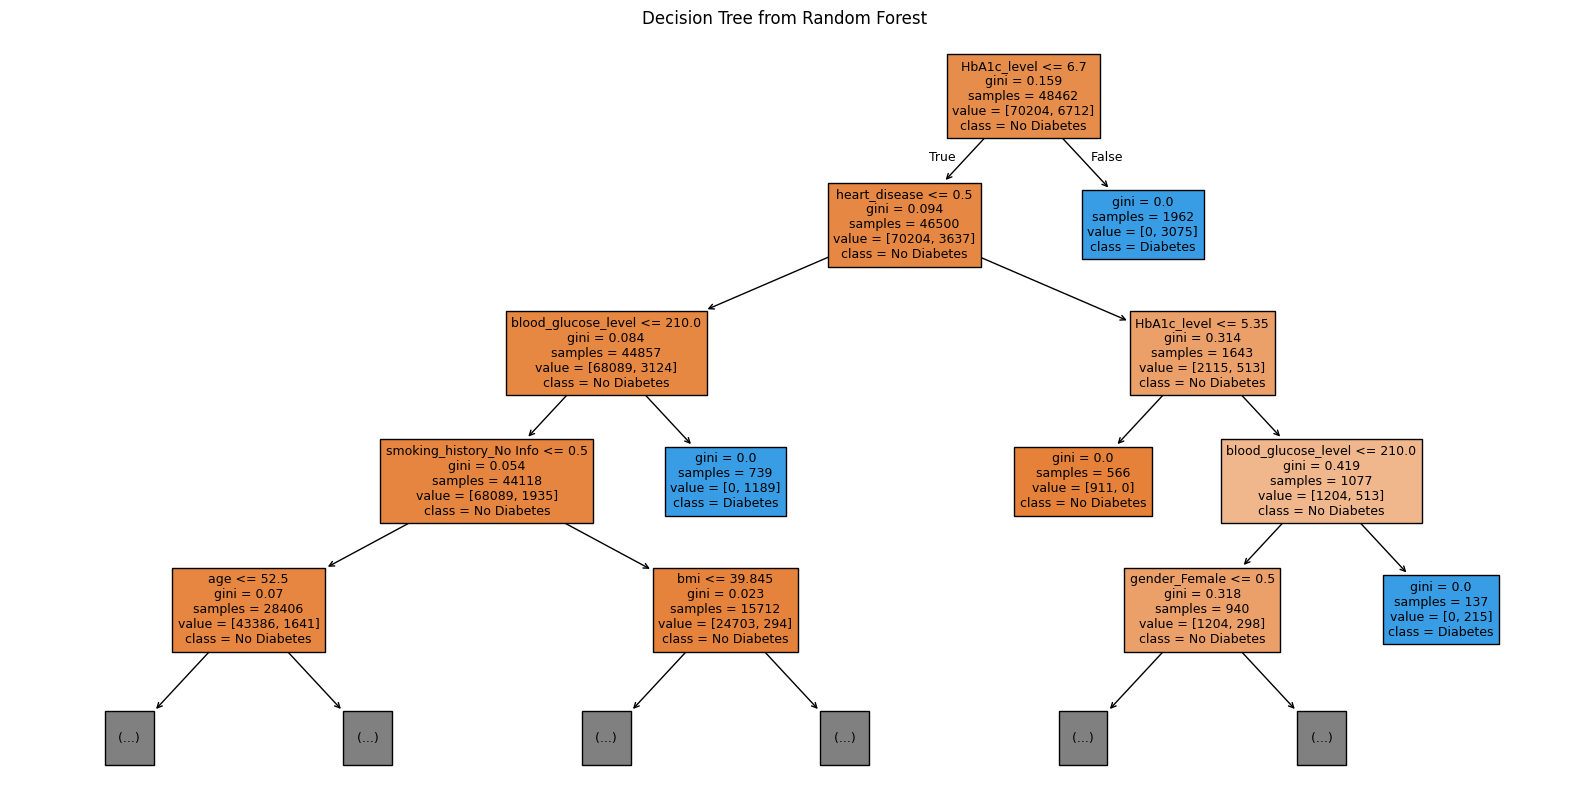

In [33]:
from sklearn.tree import plot_tree

# Extrahovanie prvého stromu z Random Forest modelu
tree = rf.estimators_[0]
# Vizualizácia stromu pomocou plot_tree
plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=list(X_train.columns), class_names=["No Diabetes", "Diabetes"], max_depth=4, filled=True, fontsize=9)
plt.title("Decision Tree from Random Forest")
plt.show()

**Uzly (Nodes):**
- Každý uzol reprezentuje rozhodovanie na základe určitej premennej (feature) a jej hodnoty.

**Hodnoty v uzloch:**
- gini: Giniho index - nižšie hodnoty znamenajú, že väčšina vzoriek v uzle patrí do jednej triedy.
- samples: Počet vzoriek, ktoré sa dostali do daného uzla. Každý strom v Random Foreste sa učí na inej náhodnej vzorke (bootstrap), preto súčet nie je rovný veľkosti tréningových dát.
- value: Počet vzoriek v každej triede (pri bootstrap vzorke ide o vážené počty).
- class: Trieda, ktorá dominuje v tomto uzle (napr. "No Diabetes" alebo "Diabetes").

**Rozvetvenie stromu:**
- Vetva True (vľavo): Znamená, že podmienka v uzle je splnená.
- Vetva False (vpravo): Znamená, že podmienka v uzle nie je splnená.

Zobrazené sú len prvé 3 úrovne jedného stromu. Výsledná predikcia Random Forestu je hlasovanie všetkých stromov.

**Prvý uzol (koreň):**
- HbA1c_level <= 6.7 - ak áno, záznam pokračuje ľavou vetvou. Ak nie, ide doprava do listu, kde sú iba diabetici (gini = 0). Zodpovedá to zisteniu z prieskumu dát, že všetky záznamy s HbA1c nad 6.6 patria do triedy diabetes.

**Druhý uzol:**
- heart_disease <= 0.5 - rozdelí ľudí bez srdcového ochorenia (vľavo) a so srdcovým ochorením (vpravo).

**Tretí uzol:**
- blood_glucose_level <= 210 - ak je glukóza vyššia, záznam ide do listu, kde sú opäť iba diabetici. Vo vetve so srdcovým ochorením strom kontroluje HbA1c <= 5.35; v tomto strome pod touto hodnotou nie je žiadny diabetik.

Ide o jeden zo 100 stromov a len o jeho prvé tri úrovne. Ostatné stromy sa učia na iných náhodných vzorkách a môžu mať iné rozdelenia, preto z jedného stromu nemožno usudzovať o celom modeli.

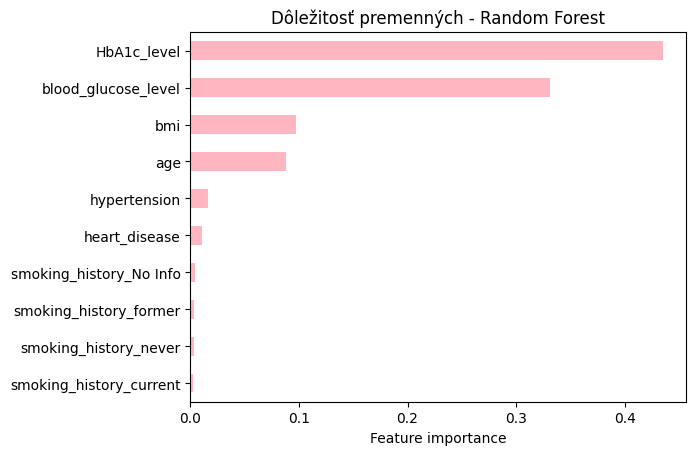

In [34]:
#funkcia feature_importances_ funguje len pre niektoré typy algoritmov (Decision Tree, Random Forest)
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(10).sort_values().plot(kind="barh", color="lightpink")
plt.title("Dôležitosť premenných - Random Forest")
plt.xlabel("Feature importance")
plt.show()

Tento graf ukazuje dôležitosť jednotlivých atribútov v modeli Random Forest (10 najdôležitejších). Najvyššiu dôležitosť má HbA1c_level (asi 0.43), za ním blood_glucose_level (asi 0.33). Spolu tvoria viac ako tri štvrtiny celkovej dôležitosti. Nasledujú bmi a age, hypertenzia a srdcové ochorenie majú malú dôležitosť a pohlavie a fajčenie takmer žiadnu.

Pri interpretácii treba mať na pamäti:
- Tento typ dôležitosti (pokles Giniho indexu na tréningových dátach) zvýhodňuje premenné s veľkým počtom rôznych hodnôt. Vyššia dôležitosť bmi oproti veku preto nemusí znamenať, že bmi je pre predikciu užitočnejšie. Spoľahlivejšie by to ukázala napríklad permutation importance na testovacích dátach.
- Dôležitosť hovorí o tom, ktoré premenné model využíva, nie o tom, čo diabetes spôsobuje.

In [35]:
new_input = pd.DataFrame([{
    "gender": "Male", "age": 45, "hypertension": 1, "heart_disease": 1,
    "smoking_history": "never", "bmi": 28.5, "HbA1c_level": 6.8, "blood_glucose_level": 120
}])
# rovnaké one-hot kódovanie ako pri tréningu; chýbajúce stĺpce doplníme nulami
new_input_encoded = pd.get_dummies(new_input, columns=['gender', 'smoking_history'], dtype=int)
new_input_encoded = new_input_encoded.reindex(columns=X_train.columns, fill_value=0)

new_data_point_pred = rf.predict(new_input_encoded)
print(f'Prediction: {new_data_point_pred[0]}')
print(f'Pravdepodobnosť diabetu podľa modelu: {rf.predict_proba(new_input_encoded)[0, 1]:.2f}')

Prediction: 1
Pravdepodobnosť diabetu podľa modelu: 0.93


Model pre tohto pacienta predpovedá diabetes. Jeho HbA1c je 6.8, teda nad hodnotou 6.6, nad ktorou sú v datasete iba diabetici. Hodnota 0.93 je priemer odhadov všetkých stromov. Nie je to kalibrovaná pravdepodobnosť, preto ju netreba interpretovať ako skutočné riziko pacienta.

## Záver

- Z testovaných modelov dosiahol najlepšie výsledky optimalizovaný Random Forest: na testovacích dátach F1 0.80, precision 0.97, recall 0.68 a accuracy 96.9 %. Model dobre rozpoznáva ľudí bez diabetu, no približne tretinu diabetikov (551 z 1 696) neodhalí.
- Logistická regresia, KNN a SVM dosiahli podobné výsledky (F1 okolo 0.73) a rozdiely medzi nimi sú v rámci rozptylu krížovej validácie.
- Accuracy nie je pri nevyvážených triedach vhodná hlavná metrika. Model, ktorý vždy predpovedá „bez diabetu“, má accuracy 91 % a F1 0.
- V tomto datasete sú najvýznamnejšie premenné HbA1c a glukóza. Záznamy s HbA1c nad 6.6 alebo glukózou nad 200 patria vždy do triedy diabetes. Zvyšní diabetici majú hodnoty v rovnakom rozsahu ako ľudia bez diabetu a žiadny z modelov ich nerozpoznáva dobre. To pravdepodobne obmedzuje recall všetkých modelov.
